## EDA - Exploratory Data Analysis

### ANALYSIS OF THE REALDONALDTRUMP DATASET

'First rows:\n'

,id,link,content,date,retweets,favorites,mentions,hashtags
0,1698308935,https://twitter.com/realDonaldTrump/status/169...,Be sure to tune in and watch Donald Trump on L...,2009-05-04 13:54:25,510,917,NaN,NaN
1,1701461182,https://twitter.com/realDonaldTrump/status/170...,Donald Trump will be appearing on The View tom...,2009-05-04 20:00:10,34,267,NaN,NaN
2,1737479987,https://twitter.com/realDonaldTrump/status/173...,Donald Trump reads Top Ten Financial Tips on L...,2009-05-08 08:38:08,13,19,NaN,NaN
3,1741160716,https://twitter.com/realDonaldTrump/status/174...,New Blog Post: Celebrity Apprentice Finale and...,2009-05-08 15:40:15,11,26,NaN,NaN
4,1773561338,https://twitter.com/realDonaldTrump/status/177...,"""My persona will never be that of a wallflower...",2009-05-12 09:07:28,1375,1945,NaN,NaN



Dataset shape: (43352, 8)

Columns:
- id
- link
- content
- date
- retweets
- favorites
- mentions
- hashtags

BASIC DATASET INFORMATION:
<class 'pandas.DataFrame'>
RangeIndex: 43352 entries, 0 to 43351
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         43352 non-null  int64
 1   link       43352 non-null  str  
 2   content    43352 non-null  str  
 3   date       43352 non-null  str  
 4   retweets   43352 non-null  int64
 5   favorites  43352 non-null  int64
 6   mentions   20386 non-null  str  
 7   hashtags   5583 non-null   str  
dtypes: int64(3), str(5)
memory usage: 2.6 MB

MISSING VALUES:
id               0
link             0
content          0
date             0
retweets         0
favorites        0
mentions     22966
hashtags     37769
dtype: int64

Basic statistics:


,id,retweets,favorites
count,4.335200e+04,43352.000000,43352.000000
mean,6.418822e+17,6264.766908,26234.241788
std,3.270437e+17,11120.363335,47705.445640
min,1.698309e+09,0.000000,0.000000
25%,3.645313e+17,27.000000,30.000000
50%,5.852812e+17,396.500000,369.000000
75%,9.076133e+17,10753.000000,45784.000000
max,1.273443e+18,302269.000000,835575.000000


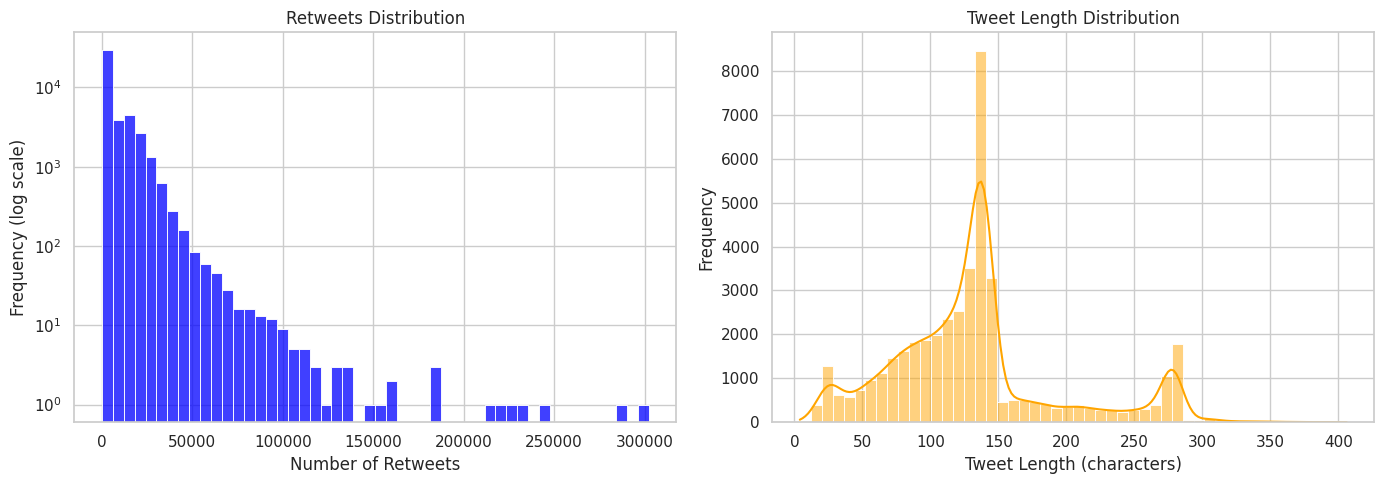

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data that should already be downloaded from Kaggle
df = pd.read_csv("../data/raw/realdonaldtrump.csv")

display("First rows:\n",df.head())

print(f"\nDataset shape: {df.shape}")

print("\nColumns:")
for col in df.columns:
    print(f"- {col}")

# Check columns and basic info
print("\nBASIC DATASET INFORMATION:")
df.info()

# Check for missing values
print("\nMISSING VALUES:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic statistics:")
display(df.describe())

# Calculate tweet lengths
# We use the 'content' column, cast to string just in case, and count characters
df['tweet_length'] = df['content'].astype(str).apply(len)

# Basic plots (Retweets and Tweet length distributions)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Retweets distribution
# Using log scale because tweets with extremely high engagement would skew the plot
sns.histplot(df['retweets'], bins=50, kde=False, ax=axes[0], color='blue')
axes[0].set_title('Retweets Distribution')
axes[0].set_xlabel('Number of Retweets')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_yscale('log')

# Plot B: Tweet length distribution
sns.histplot(df['tweet_length'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Tweet Length Distribution')
axes[1].set_xlabel('Tweet Length (characters)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### ANALYSIS OF THE TRUMPTWEETS DATASET

In [2]:
df2 = pd.read_csv("../data/raw/trumptweets.csv")

print("\nFirst rows of the trumptweets dataset:")
display(df2.head())
print("\nColumns in the trumptweets dataset:")
for col in df2.columns:
    print(f"- {col}")
print("\nShape of the trumptweets dataset:")
print(df2.shape)
print("\nMissing values in the trumptweets dataset:")
print(df2.isnull().sum())


First rows of the trumptweets dataset:


,id,link,content,date,retweets,favorites,mentions,hashtags,geo
0,1698308935,https://twitter.com/realDonaldTrump/status/169...,Be sure to tune in and watch Donald Trump on L...,2009-05-04 20:54:25,500,868,NaN,NaN,NaN
1,1701461182,https://twitter.com/realDonaldTrump/status/170...,Donald Trump will be appearing on The View tom...,2009-05-05 03:00:10,33,273,NaN,NaN,NaN
2,1737479987,https://twitter.com/realDonaldTrump/status/173...,Donald Trump reads Top Ten Financial Tips on L...,2009-05-08 15:38:08,12,18,NaN,NaN,NaN
3,1741160716,https://twitter.com/realDonaldTrump/status/174...,New Blog Post: Celebrity Apprentice Finale and...,2009-05-08 22:40:15,11,24,NaN,NaN,NaN
4,1773561338,https://twitter.com/realDonaldTrump/status/177...,"""My persona will never be that of a wallflower...",2009-05-12 16:07:28,1399,1965,NaN,NaN,NaN



Columns in the trumptweets dataset:
- id
- link
- content
- date
- retweets
- favorites
- mentions
- hashtags
- geo

Shape of the trumptweets dataset:
(41122, 9)

Missing values in the trumptweets dataset:
id               0
link             0
content          0
date             0
retweets         0
favorites        0
mentions     18655
hashtags     35312
geo          41122
dtype: int64


### DIFFERENCE BETWEEN DATASETS

In [3]:
df_ids = set(df["id"])
df2_ids = set(df2["id"])

print("Common tweets:", len(df_ids & df2_ids))
print("Only in realdonaldtrump:", len(df_ids - df2_ids))
print("Only in trumptweets:", len(df2_ids - df_ids))

Common tweets: 41104
Only in realdonaldtrump: 2248
Only in trumptweets: 18


### ENGAGEMENT LEVEL ANALYSIS

DEFINING CLASSIFICATION THRESHOLDS
Threshold for Low Engagement (Bottom 33.33%): Up to 53 retweets
Threshold for Medium Engagement (Middle 33.33%): 54 to 4558 retweets
Threshold for High Engagement (Top 33.33%): More than 4558 retweets



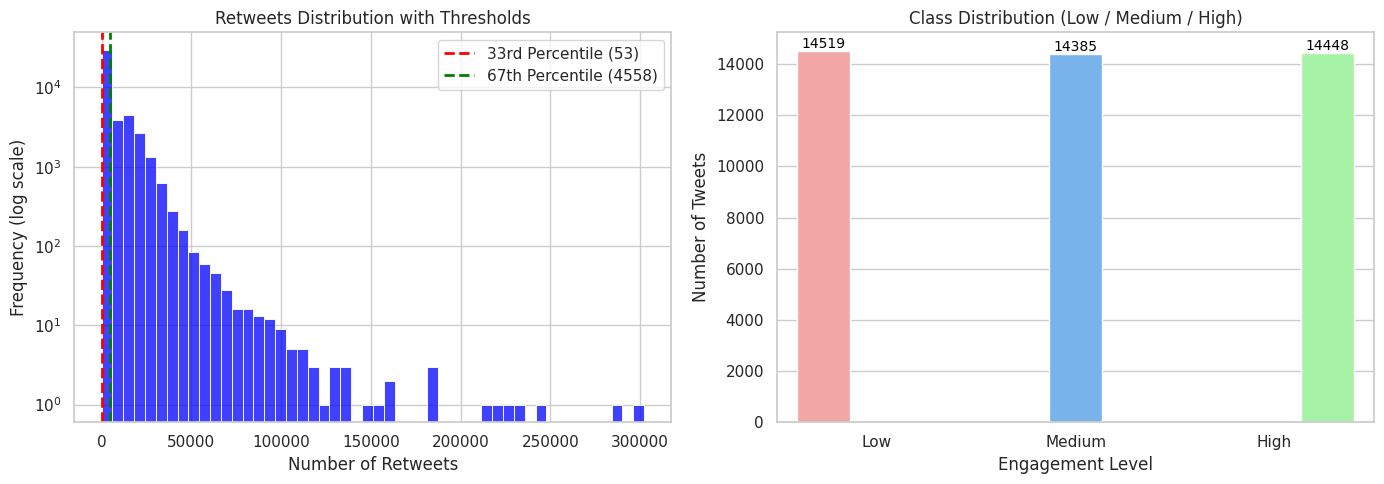

In [4]:
# Calculate the 33rd and 67th percentiles for 'retweets'
p33 = df['retweets'].quantile(0.3333)
p67 = df['retweets'].quantile(0.6667)

print("DEFINING CLASSIFICATION THRESHOLDS")
print(f"Threshold for Low Engagement (Bottom 33.33%): Up to {int(p33)} retweets")
print(f"Threshold for Medium Engagement (Middle 33.33%): {int(p33) + 1} to {int(p67)} retweets")
print(f"Threshold for High Engagement (Top 33.33%): More than {int(p67)} retweets\n")

# Create a new column 'engagement_level' based on these thresholds
def categorize_engagement(retweets: int) -> str:
    """
    Categorizes engagement level based on retweet counts.
    """
    if retweets <= p33:
        return 'Low'
    elif retweets <= p67:
        return 'Medium'
    else:
        return 'High'

df['engagement_level'] = df['retweets'].apply(categorize_engagement)

# Ensure categorical ordering for the plot (Low -> Medium -> High)
df['engagement_level'] = pd.Categorical(df['engagement_level'], categories=['Low', 'Medium', 'High'], ordered=True)

# Plotting the results
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Log-scaled histogram with threshold lines
sns.histplot(df['retweets'], bins=50, kde=False, ax=axes[0], color='blue')
axes[0].axvline(p33, color='red', linestyle='dashed', linewidth=2, label=f'33rd Percentile ({int(p33)})')
axes[0].axvline(p67, color='green', linestyle='dashed', linewidth=2, label=f'67th Percentile ({int(p67)})')
axes[0].set_title('Retweets Distribution with Thresholds')
axes[0].set_xlabel('Number of Retweets')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_yscale('log')
axes[0].legend()

# Plot B: Bar chart showing the size of each bucket
sns.countplot(data=df, x='engagement_level', hue='engagement_level', palette=['#ff9999', '#66b3ff', '#99ff99'], ax=axes[1], legend=False)
axes[1].set_title('Class Distribution (Low / Medium / High)')
axes[1].set_xlabel('Engagement Level')
axes[1].set_ylabel('Number of Tweets')

# Add count labels on top of the bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                     textcoords='offset points')

plt.tight_layout()
plt.show()

### TEMPORAL ANALYSIS: HOW ENGAGEMENT EVOLVED OVER TIME

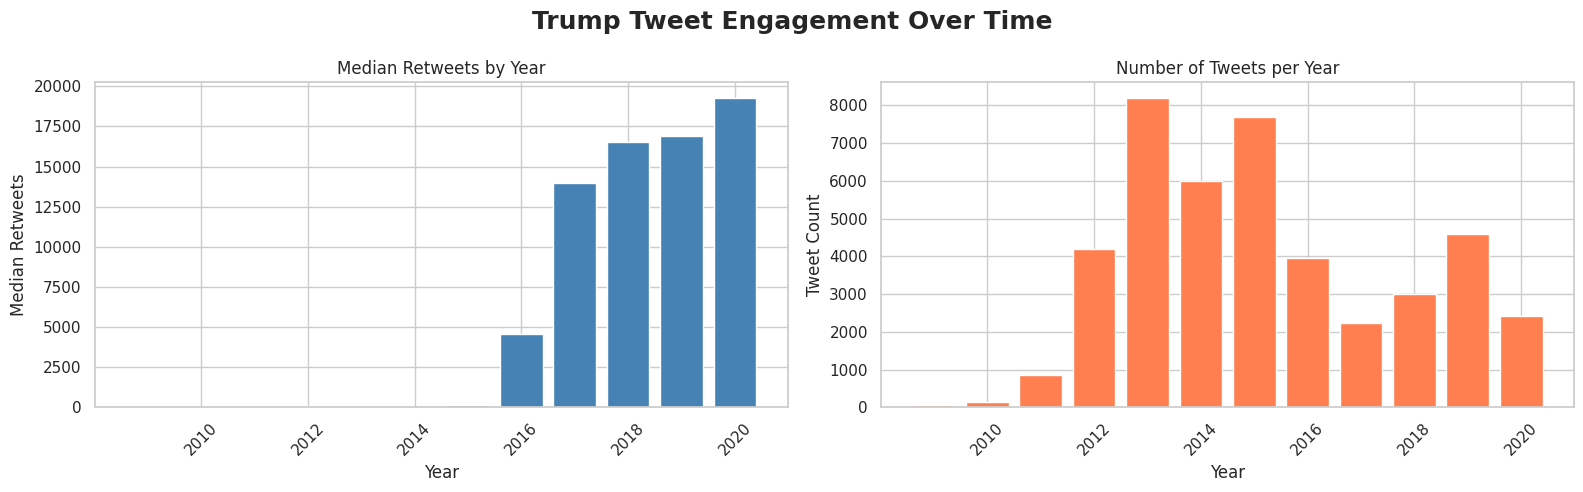

Peak engagement year: 2020 (median 19279 retweets)


In [5]:
df['date'] = pd.to_datetime(df['date'], utc=True)
df['year'] = df['date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Trump Tweet Engagement Over Time', fontsize=18, fontweight='bold')

yearly_stats = df.groupby('year')['retweets'].agg(['median', 'count'])
axes[0].bar(yearly_stats.index, yearly_stats['median'], color='steelblue', edgecolor='white')
axes[0].set_title('Median Retweets by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Retweets')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(yearly_stats.index, yearly_stats['count'], color='coral', edgecolor='white')
axes[1].set_title('Number of Tweets per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Tweet Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

peak_year = yearly_stats['median'].idxmax()
print(f"Peak engagement year: {peak_year} "
      f"(median {int(yearly_stats.loc[peak_year, 'median'])} retweets)")

### PEARSON CORRELATION: EARLY SIGNAL OF PREDICTIVE FEATURES

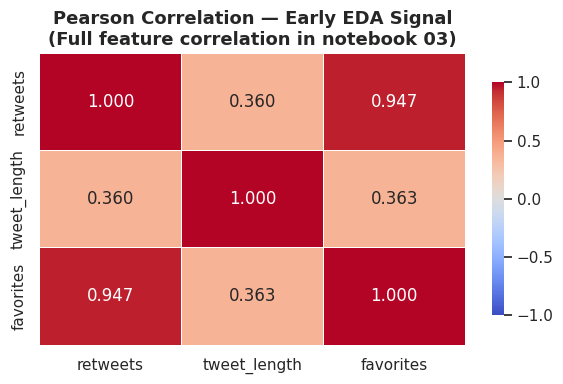

In [6]:
corr_cols = ['retweets', 'tweet_length', 'favorites']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Pearson Correlation — Early EDA Signal\n'
          '(Full feature correlation in notebook 03)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()